## M2 - Initial Implementation of Pattern Discovery in Smartphone Pricing and Hardware
#### CS - 4412
#### Victor Urey

The two discovery questions being analyzed are:
1. What natural groupings of smartphones can be discovered based on the combinations of hardware specifications across different price tiers?

2. What combinations of hardware features frequently appear across smartphone models from major brands?

To investigate these questions this document will outline:
- Clustering Analysis (using K-Means) to find natural groupings of smartphones based on the similarities of their hardware specifications.
- In the future: Association Rule Mining (using Apriori) to discover frequent combinations of hardware specifications that occur together across all smartphone models.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules

## 1. Dataset: Smartphone Specifications Dataset

This dataset contains nearly 1000 smartphone models and their hardware specifications including model name, screen size, camera resolution, included RAM, and price at release.

In [ ]:
phoneSpecs = pd.read_csv("smartphone specifications dataset.csv") # Import dataset
phoneSpecs[["model", "price", "ram_gb", "battery_mah", "screen_size_in", "rear_camera_max_mp"]].head()

,model,price,ram_gb,battery_mah,screen_size_in,rear_camera_max_mp
0,oneplus 11 5g,54999,12,5000.0,6.70,50.0
1,oneplus nord ce 2 lite 5g,19989,6,5000.0,6.59,64.0
2,samsung galaxy a14 5g,16499,4,5000.0,6.60,50.0
3,motorola moto g62 5g,14999,6,5000.0,6.55,50.0
4,realme 10 pro plus,24999,6,5000.0,6.70,108.0


In [ ]:
phoneSpecs[["model", "price", "ram_gb", "battery_mah", "screen_size_in", "rear_camera_max_mp"]].describe() # Show important columns

,price,ram_gb,battery_mah,screen_size_in,rear_camera_max_mp
count,968.000000,968.000000,957.000000,967.000000,952.000000
mean,32745.954545,7.641529,4819.935214,6.535998,50.737395
std,39707.710721,23.123619,1012.724563,0.381498,33.209502
min,2999.000000,1.000000,1500.000000,2.400000,2.000000
25%,12999.000000,4.000000,4500.000000,6.500000,48.000000
50%,19999.000000,6.000000,5000.000000,6.580000,50.000000
75%,35992.250000,8.000000,5000.000000,6.670000,64.000000
max,650000.000000,512.000000,22000.000000,8.030000,200.000000


Before analyzing these datasets there are a few values that must be cleaned:
- Missing values in categories like operating system, or rear camera specifications
- Inconsistent phone model naming
- Possible duplicates (or variations of the same model)
- Model name and Brand in the same column, should be split into 2 columns
- Pricing values are represented without decimals (1000 -> 10.00)

In [ ]:
phoneSpecs.isnull().sum() # Overview of null columns

model                      0
price                      0
rating                     0
os                        26
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
storage_gb                 0
battery_mah               11
fast_charge_w            204
screen_size_in             1
resolution                 1
refresh_rate_hz          360
display_type              85
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        16
front_camera_mp           25
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       468
dtype: int64

In [ ]:
phoneSpecs = phoneSpecs.dropna(subset=['model', 'price']) # Removes rows with NULL values in 'model' or 'price'

This dataset includes both the brand and the model information in the same cell (e.g. iPhone 14 Pro-Max). Solving this requires that we:
1. Split the brand and model names (iPhone, 14 Pro-Max)
2. Clean special characters (Pro-Max -> Pro Max)


In [ ]:
# Split brand and model names into two columns
def splitBrandModel(text): # Standardize names into lowercase
    text = str(text).lower().strip()
    piece = text.split(" ", 1)
    return piece[0], piece[1]

# Create new columns (brand & model)
phoneSpecs["brand"], phoneSpecs["model"] = zip(*phoneSpecs["model"].apply(splitBrandModel)) 

# Moves new brand column to column 0
column = phoneSpecs.pop("brand")
phoneSpecs.insert(0, "brand", column)

# Remove duplicate prices per model, keep median price
median = phoneSpecs.groupby(['brand', 'model'])['price'].median().reset_index()
median = median.rename(columns={'price': 'median price'})
phoneSpecs = phoneSpecs.merge(median, on=['brand', 'model'])
phoneSpecs = phoneSpecs[phoneSpecs['price'] == phoneSpecs['median price']]

phoneSpecs = phoneSpecs.drop(columns='median price')
phoneSpecs = phoneSpecs.reset_index(drop=True)

# Price formatting
phoneSpecs["newPrice"] = phoneSpecs["price"] // 100 # Remove cents
column = phoneSpecs.pop("price")
phoneSpecs.rename(columns={"newPrice": "price"}, inplace=True) # Rename new column back to price
column = phoneSpecs.pop("price")
phoneSpecs.insert(0, "price", column) # Move price column to front

phoneSpecs[["brand", "model", "price", "ram_gb", "battery_mah", "screen_size_in", "rear_camera_max_mp"]].head()

,brand,model,price,ram_gb,battery_mah,screen_size_in,rear_camera_max_mp
0,oneplus,11 5g,549,12,5000.0,6.70,50.0
1,motorola,moto g62 5g,149,6,5000.0,6.55,50.0
2,xiaomi,redmi note 12 pro plus,299,8,4980.0,6.67,200.0
3,oneplus,nord 2t 5g,289,8,4500.0,6.43,50.0
4,oppo,a78,189,8,5000.0,6.56,50.0


## 2. Exploratory Data Analysis (EDA)
#### 2.1 Univariate Analysis

In [ ]:
phoneSpecs[["brand", "model", "price", "ram_gb", "battery_mah", "screen_size_in", "rear_camera_max_mp"]].describe()

,price,ram_gb,battery_mah,screen_size_in,rear_camera_max_mp
count,669.000000,669.000000,664.000000,668.000000,653.000000
mean,344.336323,8.343797,4790.027108,6.533129,51.849923
std,422.541706,27.740644,1161.402851,0.429087,34.281479
min,29.000000,1.000000,1500.000000,2.400000,2.000000
25%,149.000000,4.000000,4500.000000,6.500000,48.000000
50%,224.000000,8.000000,5000.000000,6.580000,50.000000
75%,399.000000,8.000000,5000.000000,6.700000,64.000000
max,6500.000000,512.000000,22000.000000,8.030000,200.000000


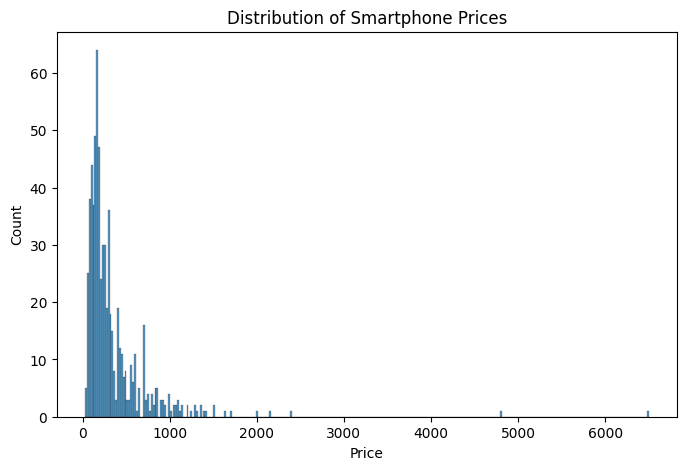

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(phoneSpecs['price'], bins=300) # 300 Was chosen for visualization purposes
plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The distribution of smartphone prices is very heavily left skewed by account of the large outliers in the dataset. These large values may be in their own cluster and the price values below $2000 is where most of the other clusters will lie.

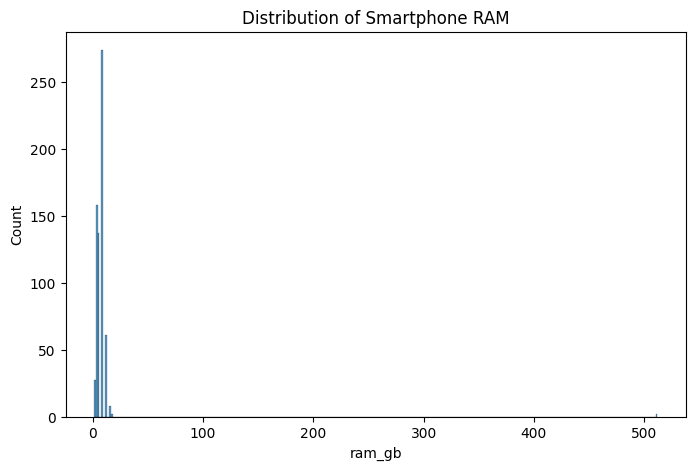

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(phoneSpecs['ram_gb'], bins=300) # 300 was chosen for visualization purposes
plt.title("Distribution of Smartphone RAM")
plt.show()

Smartphone RAM has either:
- A few large outliers that need to be removed
- Experimental devices that should be kept as valid data points

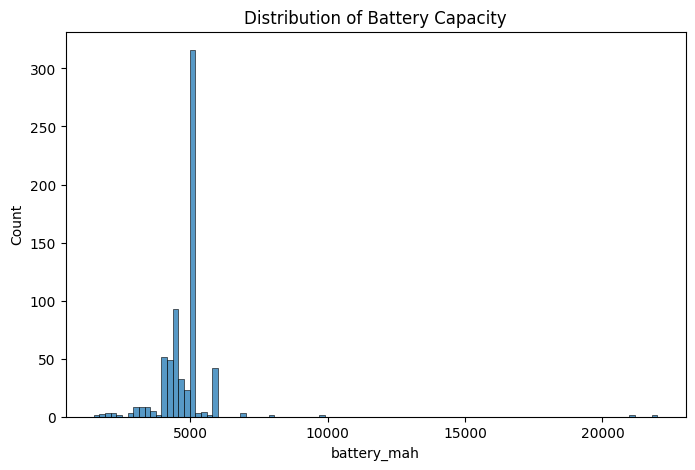

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(phoneSpecs['battery_mah'], bins=100) # 100 was chosen to show spread
plt.title("Distribution of Battery Capacity")
plt.show()

Battery capacity shows a good spread of ranges, slightly right skewed, and has a few outliers above 20,000 mAh. It seems that most devices sit between the 2500 and 6000 range, with a few devices pushing past that. 

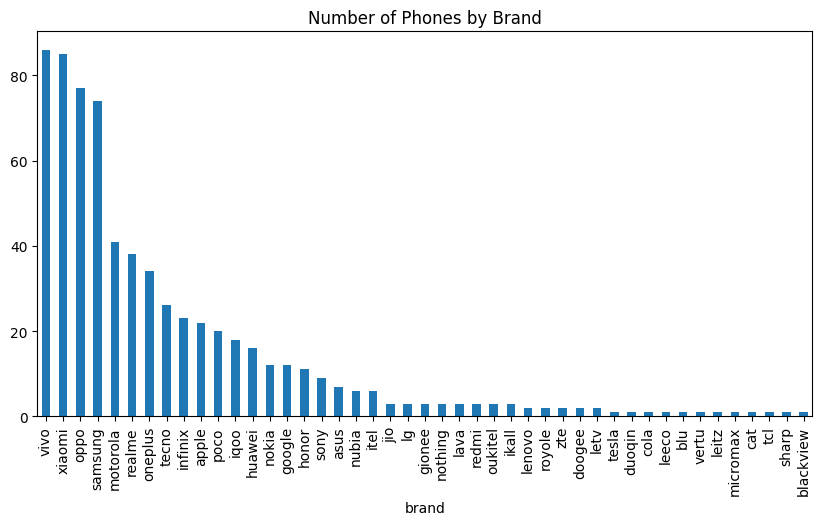

In [ ]:
phoneSpecs['brand'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Number of Phone Models by Brand")
plt.show()

This is a visualization of the dominating brands in this dataset. Vivo, Xiaomi, Oppo, and Samsung are the top four most common devices on this list. This dataset will provide meaningful data across all brands but it is important to remember which brands may be skewing data in one direction or another.

#### 2.1 Bivariate and Multivariate Analysis

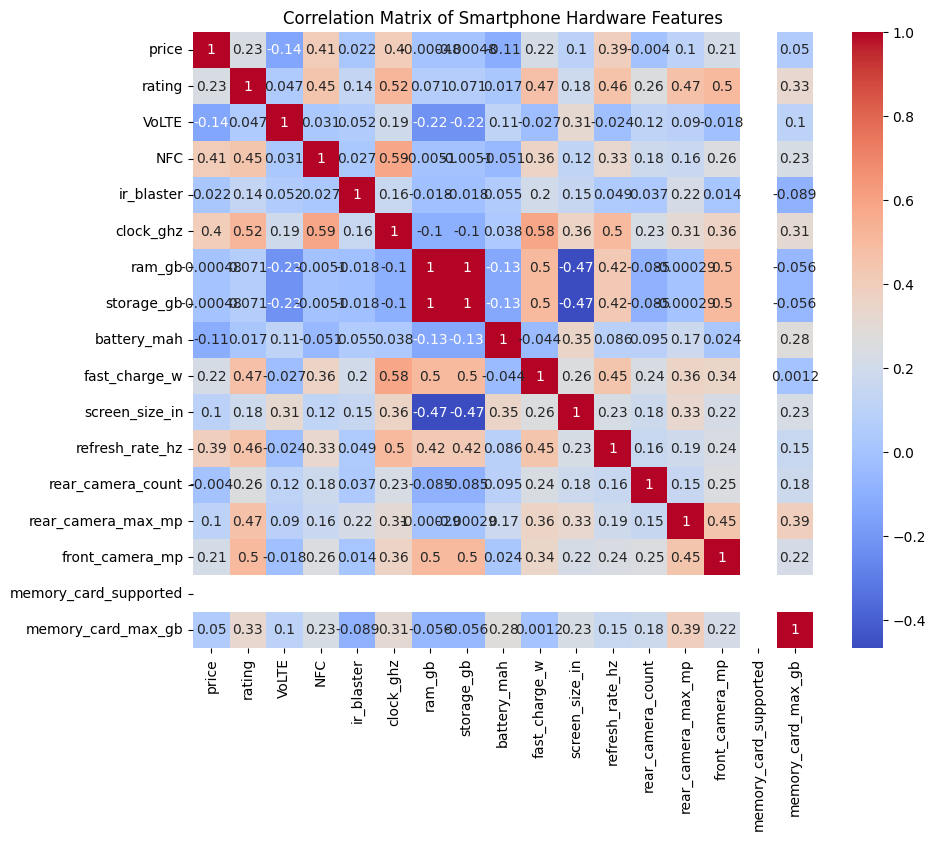

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(phoneSpecs.corr(numeric_only=True), annot=True, cmap='coolwarm') # Setup for heat map
plt.title("Correlation Matrix of Smartphone Hardware Features")
plt.show()

The correlation matrix of features provides a good overview of how one variable may be affecting another. 
- Surprisingly, price has relatively weak correlations with most other features. This means that pricing for high-end devices is comprised of combinations of RAM, Camera Resolution, Battery Capacity, and Screen Size, not just one feature alone.
- The strong correlation between ram and storage is to be expected from hardware pairings. Only one of these should be included in clustering.

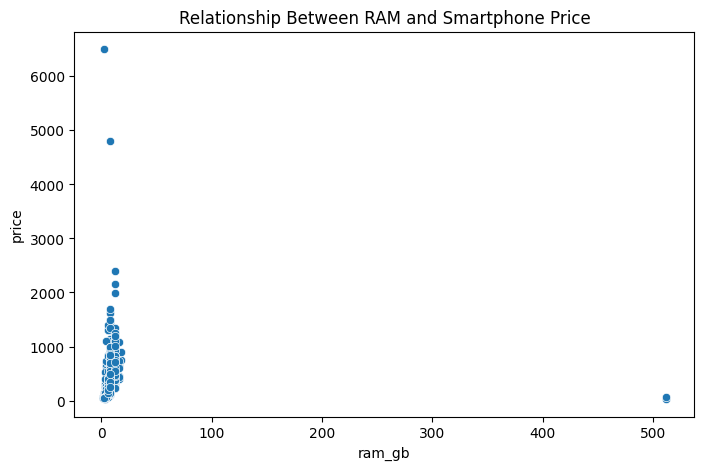

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=phoneSpecs, x='ram_gb', y='price')
plt.title("RAM vs Smartphone Price")
plt.show()

Among most phone models, it seems that RAM only slightly affects the pricing of smartphones. This, given the data from the correlation matrix, leads me to believe that individual hardware features may not produce natural groups of devices into price tiers. 

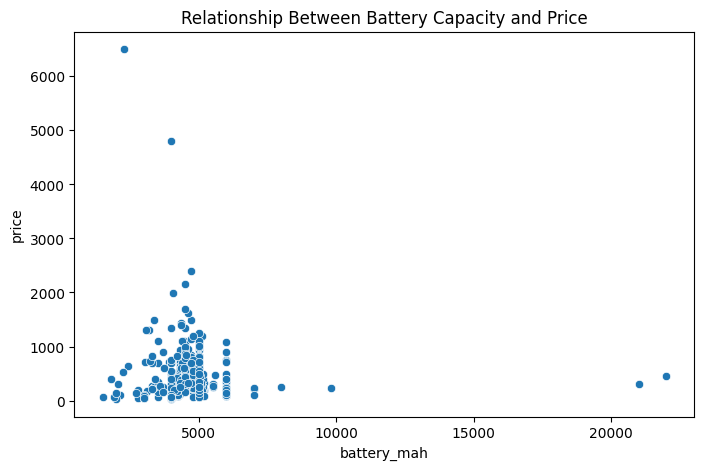

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=phoneSpecs, x='battery_mah', y='price')
plt.title("Battery Capacity vs Price")
plt.show()

This graph demonstrates a slightly wider spread of values between battery and pricing. This may be useful for analyzing devices with large batteries since they may be naturally grouped into their own cluster later on.

In [16]:
phoneSpecs.groupby('brand')[['ram_gb','battery_mah','rear_camera_max_mp','screen_size_in']].mean().sort_values('ram_gb', ascending=False)

,ram_gb,battery_mah,rear_camera_max_mp,screen_size_in
brand,,,,
jio,172.666667,3266.666667,6.666667,4.633333
nokia,47.916667,4730.833333,85.181818,6.203333
tesla,16.000000,5000.000000,50.000000,6.730000
lenovo,14.000000,5300.000000,64.000000,6.710000
asus,13.714286,5757.142857,54.666667,6.657143
leitz,12.000000,5000.000000,9.000000,6.600000
sharp,12.000000,3730.000000,48.000000,6.500000
doogee,10.000000,14000.000000,108.000000,6.440000
nubia,9.333333,5175.000000,59.333333,6.756667


Overview of the mean values in each of the important variables, sorted by brand. May show patterns in the future about specific hardware combinations and their frequency.

#### 2.3 Connecting EDA to Discovery Questions

##### Discovery Question 1: What natural groupings of smartphones can be discovered based on combinations of hardware specifications across different price tiers?

The EDA shows that all hardware specifications vary across all ranges of smartphone pricing. It reveals that phone models are spread across multiple price tiers rather than being centrally grouped. This range of devices is useful for Clustering and Association rules because they can further discover the natural groupings that these ranges represent.

##### Discovery Question 2: What combinations of hardware features frequently appear across smartphone models from major brands?

The EDA reveals that many smartphone models share similar combinations of hardware even across brands. These repeating combinations show that certain hardware features may be worth looking at further with association rule mining. 

These results are good news for both discovery questions since tools like Clustering and Association Rules will be helpful for expanding on both.

## 3. Data Preprocessing
#### 3.1 Missing Values
The smartphone specifications dataset contains some missing values across important categories like battery capacity, ram in gb, or camera specifics. Instead of removing all the entries in the dataset that were missing a value, I only removed entries in the table that were missing any of these five variables:
- Price
- RAM
- Battery Capacity
- Rear Camera Resolution
- Screen Size


In [ ]:
phoneSpecs = phoneSpecs.dropna(subset=['price','ram_gb','battery_mah','rear_camera_max_mp','screen_size_in'])

Removing all values with missing values was detrimental to the pattern analysis because it would remove nearly half of the entire table. For this reason I decided to focus on key features that better reflect the most popoular hardware specifications we see in phones today. 

##### 3.2 Outliers
There were a few apparent outliers in price, RAM, and in battery life. The EDA discovered these outliers and plotted below are the outliers for price in the dataset:

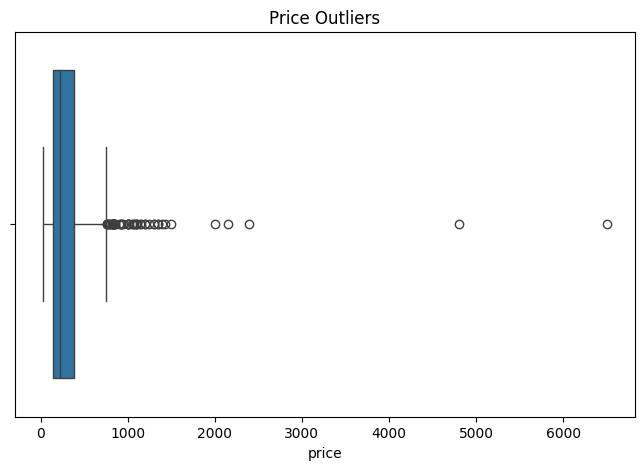

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=phoneSpecs['price'])
plt.title("Outliers in Price")
plt.show()

Based on the plot and other specifications, I think these extreme values represent actual high-end devices rather than errors. I decided to keep these devices in the dataset so that the entire range of devices was considered.

#### 3.3 Connecting Feature Engineering to Discovery Questions
##### Discovery Question 1. What natural groupings of smartphones can be discovered based on combinations of hardware specifications across different price tiers?
Price tiers will allow for association rule mining and clustering to identify combinations of hardware within each category. 

##### Discovery Question 2. What combinations of hardware features frequently appear across smartphone models from major brands?
The data cleaning and standardization steps are useful for making sure devices from brands are properly grouped together. 


## 4. First Mining Technique
#### 4.1 Clustering
Clustering supports the first discovery question because it helps discover natural groupings based on patterns in hardware specs. Clusters may correspond to the three tiers and may show reccuring combinations of hardware features within each category.

#### 4.2 Clustering Implementation (K-Means)
For the clustering I used main five variables:
- Price
- RAM
- Battery Capacity
- Rear Camera Resolution
- Screen Size

##### 4.3 Scaling
Because variables like battery_mah had values in the thousands and screen_size_in had values between 5-10 inches, I had to scale the data to contribute equally to the clustering. I scaled using z-score standardization to create normalized values with a mean of 0 and standard deviation of 1.

##### 4.4 Number of Clusters
I used the elbow method to find a proper value for k for use in K-Means. After plotting different numbers of clusters I found that k = 6 provided the best results, somewhat correlating with my intial speculation that phones may naturally fall into various tiers based on their hardware specifications.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = phoneSpecs[['ram_gb', 'battery_mah', 'rear_camera_max_mp', 'screen_size_in', 'price']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=6, random_state=42) # k = 6 
phoneSpecs['cluster'] = kmeans.fit_predict(scaled_features)


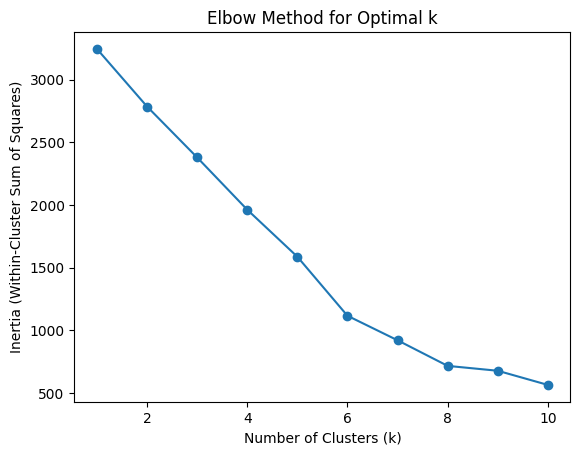

             ram_gb   battery_mah  rear_camera_max_mp  screen_size_in  \
cluster                                                                 
0          5.000000   2892.600000           20.200000        5.314667   
1          7.470449   4859.952719           53.203310        6.619740   
2          4.240876   4535.467153           13.386861        6.371241   
3         10.000000  21500.000000           86.000000        6.680000   
4          8.140845   4946.056338          126.140845        6.722817   
5        512.000000   2000.000000            2.000000        2.400000   

               price  
cluster               
0        1424.800000  
1         324.888889  
2         187.547445  
3         379.000000  
4         421.436620  
5          29.000000  


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method Visualized")
plt.show()

# Cluster Data values
cluster_summary = phoneSpecs.groupby('cluster')[features.columns].mean()
print(cluster_summary)

##### 4.5 Cluster Interpretation
Above is the result of the K-Means clustering with a value of k = 6. The following conclusions were reached:
- Cluster 0: Showed phones with smaller screens and batteries, moderate RAM, but an abnormal, high price value. Could represent data entry error or even a difference in currency.
- Cluster 1: This cluster contained phones with larger screens, strong battery life, and good cameras.
- Cluster 2: Noteably showed lower RAM, decent cameras and lower pricing. May represent a smaller or more proprietary phone model aimed at budget consumers.
- Cluster 3: Largly abnormal battery value. This cluster may contain special performance devices or older phones with different battery technology.
- Cluster 4: By far the highest combination of RAM, camera resolutions, large batteries and big screens. This is the high-end phone model cluster.
- Cluster 5: Another outlier in the cluster makeup. This cluster had a very high 512gb of ram while having small batteries and screens. Could be a data error or a few phones skewing the whole cluster in the RAM direction.

These six clusters support the hypothesis that phone specifications can be naturally grouped into tiers based on hardware and pricing. It seems like there may be four solid tiers for smartphone grouping, the other two representing some form of data error or just single-use, proof-of-concept devices.

## 5. Preliminary Findings and Interpretation
#### 5.1 Connecting to Discovery Questions
##### Discovery Question 1. What combinations of hardware features correspond to different price tiers?
Using K-Means clustering it was revealed that there could be 6 distinct groups of smartphones:
- Cluster 2 could be defined as Budget Phones, having smaller RAM, cameras, and screen sizes. These phones also had the lowest prices among all others.
- Cluster 1 could be defined as the modern Mid-Level smartphone. These phones had decent RAM, battery lives, and bigger phone screens.
- Cluster 4 could be defined as the highest-end phone on the market today. These phones had the largest RAM and the best cameras while remaining as large as phones in Cluster 1.
- Cluster 0 could be defined as older phones or smaller phones with very basic technology. These had very low RAM, the smallest batteries, and rather small screens. This cluster was priced abnormally high, potentially representing some form of data error.

Clusters 3 and 5 both fell into the outlier category, having very high values in RAM or battery categories. Either these clusters are dominated by special "gimmick" devices or they represent a data error with these two variables.


##### Discovery Question 2. How do certain brands prioritize specific hardware features?
- EDA revealed that some brands tend to focus on one hardware feature over others
- Using the data from K-Means, we could find the distribution of each brand and see where most of their devices lie across the main smartphone tiers. Certain brands may dominate the premium tier and others may find most of their devices in the mid-tier or budget-friendly options.

#### 6. Surprises and Limitations
Surprising findings:
- Cluster 3 had a very, very high battery value. Indicating a potential data error or extreme outlier.
- Cluster 0 had an abnormally high average price, approximately $142,000. This is quite a large red flag that there may be data in the wrong format or in the wrong currency system which fell into the wrong cluster.

Limitations:
- The clustering was incredibly affected by outliers.
- Not all phone models have their operating systems provided in the dataset. This could be a useful variable to measure in the future if those values could be found and populated.

#### 7. Next Steps
These are the goals I have for M3:
- Week 1 (Mar 6 - Mar 12): Normalize price variable with a focus on outliers, clean all data issues and re-cluster updated dataset.
- Week 2 (Mar 13 - Mar 19): Apply Apriori technique for association rules and compare to the previous weeks K-Means results.
- Week 3 (Mar 20 - Mar 26): Potentially fill in missing operating system values, integrate into clustering and association rules mining.
- Week 4 (Mar 27 - Apr 2): Finalize report and provide updated values in notebook, correct previous documents to remain current.